# Shipment Delay Prediction


## Prediction Moment

Predict delay at booking/dispatch time using only available inputs.

- Drop leakage/ID columns: `Shipment ID`, `Actual Delivery Date`
- Keep planned information and operational features
- Engineer: `planned_transit_days`, `ship_month`, `ship_weekday`

In [31]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [32]:
# Load data
df = pd.read_csv("Training Data.csv")
print("Dataset loaded: Training Data.csv")

Dataset loaded: Training Data.csv


In [33]:
# Quick checks
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["Delayed"].value_counts())
print((df["Delayed"].value_counts(normalize=True) * 100).round(2))

Shape: (20000, 11)

Dtypes:
Shipment ID                str
Origin                     str
Destination                str
Shipment Date              str
Planned Delivery Date      str
Actual Delivery Date       str
Vehicle Type               str
Distance (km)            int64
Weather Conditions         str
Traffic Conditions         str
Delayed                    str
dtype: object

Missing values:
Shipment ID                0
Origin                     0
Destination                0
Shipment Date              0
Planned Delivery Date      0
Actual Delivery Date       0
Vehicle Type             597
Distance (km)              0
Weather Conditions         0
Traffic Conditions         0
Delayed                    0
dtype: int64

Duplicate rows: 0

Target distribution:
Delayed
Yes    14757
No      5243
Name: count, dtype: int64
Delayed
Yes    73.78
No     26.22
Name: proportion, dtype: float64


In [34]:
# Keep only agreed columns (leakage-safe)
cols = [
    "Origin",
    "Destination",
    "Shipment Date",
    "Planned Delivery Date",
    "Vehicle Type",
    "Distance (km)",
    "Weather Conditions",
    "Traffic Conditions",
    "Delayed",
]

data = df[cols].copy()
print("Working data shape:", data.shape)
data.head()

Working data shape: (20000, 9)


,Origin,Destination,Shipment Date,Planned Delivery Date,Vehicle Type,Distance (km),Weather Conditions,Traffic Conditions,Delayed
0,Jaipur,Mumbai,26-04-2023,01-05-2023,Trailer,1603,Rain,Light,Yes
1,Bangalore,Delhi,09-02-2023,13-02-2023,Trailer,1237,Storm,Moderate,Yes
2,Mumbai,Chennai,19-09-2023,25-09-2023,Truck,1863,Clear,Light,No
3,Hyderabad,Ahmedabad,01-04-2023,05-04-2023,Container,1374,Clear,Light,No
4,Chennai,Kolkata,24-11-2023,26-11-2023,Container,676,Clear,Heavy,Yes


In [35]:
# Missing handling: Vehicle Type -> mode
vehicle_mode = data["Vehicle Type"].mode()[0]
data["Vehicle Type"] = data["Vehicle Type"].fillna(vehicle_mode)
print("Vehicle Type mode used:", vehicle_mode)
print("Remaining missing in Vehicle Type:", data["Vehicle Type"].isna().sum())

Vehicle Type mode used: Lorry
Remaining missing in Vehicle Type: 0


In [36]:
# Parse dates as DD-MM-YYYY
data["Shipment Date"] = pd.to_datetime(data["Shipment Date"], format="%d-%m-%Y", errors="coerce")
data["Planned Delivery Date"] = pd.to_datetime(data["Planned Delivery Date"], format="%d-%m-%Y", errors="coerce")

print("Null Shipment Date after parse:", data["Shipment Date"].isna().sum())
print("Null Planned Delivery Date after parse:", data["Planned Delivery Date"].isna().sum())

Null Shipment Date after parse: 0
Null Planned Delivery Date after parse: 0


In [37]:
# Feature engineering: planned_transit_days + month + weekday
data["planned_transit_days"] = (data["Planned Delivery Date"] - data["Shipment Date"]).dt.days
data["ship_month"] = data["Shipment Date"].dt.month
data["ship_weekday"] = data["Shipment Date"].dt.weekday

# Remove invalid negative planned_transit_days (if any)
invalid_count = (data["planned_transit_days"] < 0).sum()
if invalid_count > 0:
    print("Invalid negative planned_transit_days rows removed:", invalid_count)
    data = data[data["planned_transit_days"] >= 0].copy()

print("Data shape after feature engineering:", data.shape)
data[["Shipment Date", "Planned Delivery Date", "planned_transit_days", "ship_month", "ship_weekday"]].head()

Data shape after feature engineering: (20000, 12)


,Shipment Date,Planned Delivery Date,planned_transit_days,ship_month,ship_weekday
0,2023-04-26,2023-05-01,5,4,2
1,2023-02-09,2023-02-13,4,2,3
2,2023-09-19,2023-09-25,6,9,1
3,2023-04-01,2023-04-05,4,4,5
4,2023-11-24,2023-11-26,2,11,4


In [38]:
# Final modeling dataset: drop raw date columns
X = data.drop(columns=["Delayed", "Shipment Date", "Planned Delivery Date"])
y = data["Delayed"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", X.columns.tolist())

X shape: (20000, 9)
y shape: (20000,)
Features: ['Origin', 'Destination', 'Vehicle Type', 'Distance (km)', 'Weather Conditions', 'Traffic Conditions', 'planned_transit_days', 'ship_month', 'ship_weekday']


In [39]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 9)
X_test: (4000, 9)
y_train: (16000,)
y_test: (4000,)


In [40]:
# Preprocessing pipeline
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Distance (km)', 'planned_transit_days', 'ship_month', 'ship_weekday']
Categorical features: ['Origin', 'Destination', 'Vehicle Type', 'Weather Conditions', 'Traffic Conditions']


In [41]:
# Evaluation helper
classes = sorted(y.unique().tolist())
pos_label = "Yes" if "Yes" in classes else classes[1]


def evaluate_model(model_pipeline, model_name):
    model_pipeline.fit(X_train, y_train)

    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    train_auc, test_auc = np.nan, np.nan
    if hasattr(model_pipeline, "predict_proba"):
        idx = list(model_pipeline.classes_).index(pos_label)
        train_prob = model_pipeline.predict_proba(X_train)[:, idx]
        test_prob = model_pipeline.predict_proba(X_test)[:, idx]
        train_auc = roc_auc_score(y_train, train_prob)
        test_auc = roc_auc_score(y_test, test_prob)

    metrics = {
        "Model": model_name,
        "Train_Accuracy": accuracy_score(y_train, y_train_pred),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Train_Precision": precision_score(y_train, y_train_pred, pos_label=pos_label),
        "Test_Precision": precision_score(y_test, y_test_pred, pos_label=pos_label),
        "Train_Recall": recall_score(y_train, y_train_pred, pos_label=pos_label),
        "Test_Recall": recall_score(y_test, y_test_pred, pos_label=pos_label),
        "Train_F1": f1_score(y_train, y_train_pred, pos_label=pos_label),
        "Test_F1": f1_score(y_test, y_test_pred, pos_label=pos_label),
        "Train_ROC_AUC": train_auc,
        "Test_ROC_AUC": test_auc,
    }

    print(f"\n{model_name} - Test Classification Report")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred, labels=classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"{model_name} - Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model_pipeline, metrics


Logistic Regression - Baseline - Test Classification Report
              precision    recall  f1-score   support

          No       0.76      1.00      0.86      1049
         Yes       1.00      0.89      0.94      2951

    accuracy                           0.92      4000
   macro avg       0.88      0.94      0.90      4000
weighted avg       0.94      0.92      0.92      4000



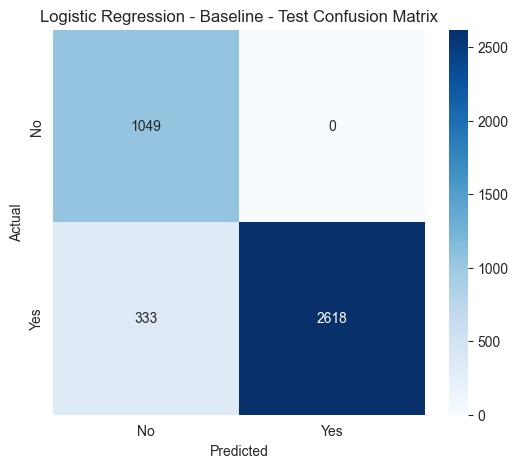

In [43]:
# Model 1A: Logistic Regression (baseline)
log_reg_base = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

log_reg_base_model, log_reg_base_metrics = evaluate_model(log_reg_base, "Logistic Regression - Baseline")


Logistic Regression - Balanced - Test Classification Report
              precision    recall  f1-score   support

          No       0.76      1.00      0.86      1049
         Yes       1.00      0.89      0.94      2951

    accuracy                           0.92      4000
   macro avg       0.88      0.94      0.90      4000
weighted avg       0.94      0.92      0.92      4000



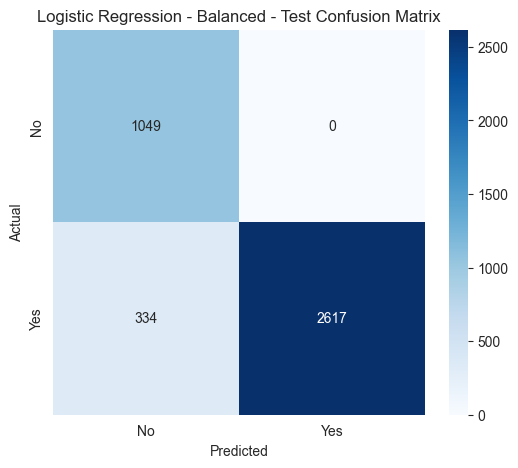

In [44]:
# Model 1B: Logistic Regression (class_weight='balanced')
log_reg_bal = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
])

log_reg_bal_model, log_reg_bal_metrics = evaluate_model(log_reg_bal, "Logistic Regression - Balanced")


Decision Tree - Baseline - Test Classification Report
              precision    recall  f1-score   support

          No       0.74      0.69      0.71      1049
         Yes       0.89      0.91      0.90      2951

    accuracy                           0.85      4000
   macro avg       0.82      0.80      0.81      4000
weighted avg       0.85      0.85      0.85      4000



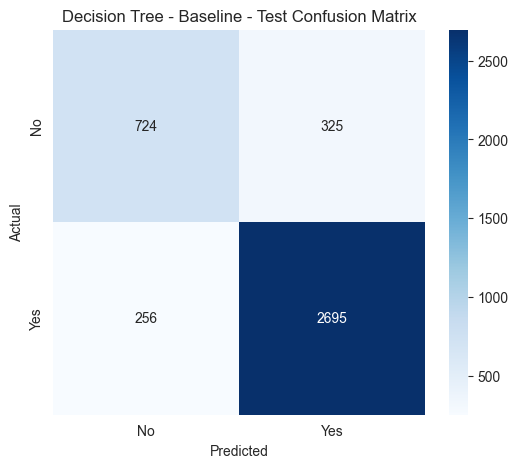

In [45]:
# Model 2A: Decision Tree (baseline)
dt_base = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

dt_base_model, dt_base_metrics = evaluate_model(dt_base, "Decision Tree - Baseline")


Decision Tree - Balanced - Test Classification Report
              precision    recall  f1-score   support

          No       0.75      0.72      0.74      1049
         Yes       0.90      0.91      0.91      2951

    accuracy                           0.86      4000
   macro avg       0.83      0.82      0.82      4000
weighted avg       0.86      0.86      0.86      4000



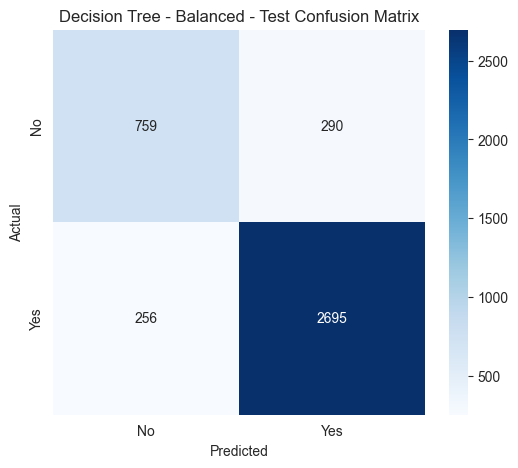

In [46]:
# Model 2B: Decision Tree (class_weight='balanced')
dt_bal = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])

dt_bal_model, dt_bal_metrics = evaluate_model(dt_bal, "Decision Tree - Balanced")


Random Forest - Baseline - Test Classification Report
              precision    recall  f1-score   support

          No       0.76      0.96      0.85      1049
         Yes       0.98      0.89      0.93      2951

    accuracy                           0.91      4000
   macro avg       0.87      0.92      0.89      4000
weighted avg       0.92      0.91      0.91      4000



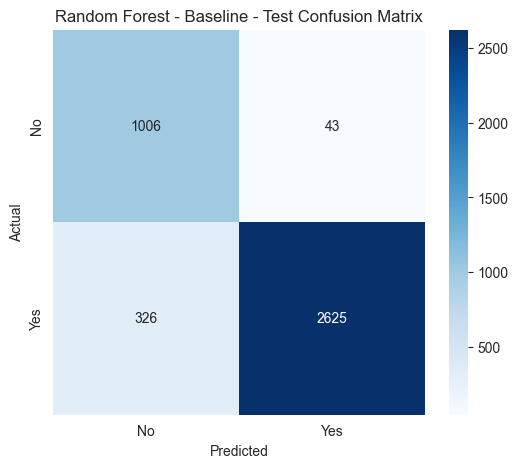

In [49]:
# Model 3A: Random Forest (baseline)
rf_base = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_base_model, rf_base_metrics = evaluate_model(rf_base, "Random Forest - Baseline")


Random Forest - Balanced - Test Classification Report
              precision    recall  f1-score   support

          No       0.76      0.96      0.85      1049
         Yes       0.98      0.89      0.94      2951

    accuracy                           0.91      4000
   macro avg       0.87      0.93      0.89      4000
weighted avg       0.92      0.91      0.91      4000



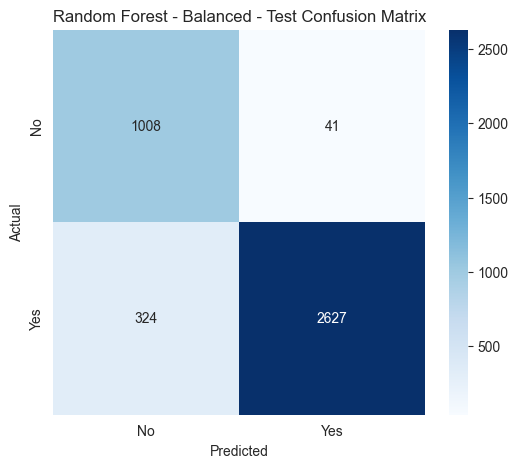

In [50]:
# Model 3B: Random Forest (class_weight='balanced')
rf_bal = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")),
])

rf_bal_model, rf_bal_metrics = evaluate_model(rf_bal, "Random Forest - Balanced")

In [51]:
# Combine model results
results_df = pd.DataFrame([
    log_reg_base_metrics,
    log_reg_bal_metrics,
    dt_base_metrics,
    dt_bal_metrics,
    rf_base_metrics,
    rf_bal_metrics,
])

results_df["F1_Gap_TrainMinusTest"] = results_df["Train_F1"] - results_df["Test_F1"]


def fit_status(row):
    if row["F1_Gap_TrainMinusTest"] > 0.10:
        return "Possible Overfitting"
    if row["Test_F1"] < 0.60:
        return "Possible Underfitting"
    return "Balanced Fit"


results_df["Fit_Diagnosis"] = results_df.apply(fit_status, axis=1)
results_df = results_df.sort_values(by="Test_F1", ascending=False).reset_index(drop=True)
results_df

,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC,F1_Gap_TrainMinusTest,Fit_Diagnosis
0,Logistic Regression - Baseline,0.917312,0.91675,1.000000,1.000000,0.887938,0.887157,0.940643,0.940205,0.946939,0.944499,0.000439,Balanced Fit
1,Logistic Regression - Balanced,0.916500,0.91650,1.000000,1.000000,0.886837,0.886818,0.940025,0.940014,0.946635,0.944504,0.000011,Balanced Fit
2,Random Forest - Balanced,0.999938,0.90875,1.000000,0.984633,0.999915,0.890207,0.999958,0.935042,1.000000,0.943828,0.064916,Balanced Fit
3,Random Forest - Baseline,0.999938,0.90775,0.999915,0.983883,1.000000,0.889529,0.999958,0.934330,1.000000,0.943891,0.065628,Balanced Fit
4,Decision Tree - Balanced,0.999938,0.86350,1.000000,0.902848,0.999915,0.913250,0.999958,0.908019,1.000000,0.818398,0.091939,Balanced Fit
5,Decision Tree - Baseline,0.999938,0.85475,1.000000,0.892384,0.999915,0.913250,0.999958,0.902696,1.000000,0.801715,0.097261,Balanced Fit


In [52]:
# Cross-validation check (weighted F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    "Logistic Regression - Baseline": log_reg_base,
    "Logistic Regression - Balanced": log_reg_bal,
    "Decision Tree - Baseline": dt_base,
    "Decision Tree - Balanced": dt_bal,
    "Random Forest - Baseline": rf_base,
    "Random Forest - Balanced": rf_bal,
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV_F1_Weighted_Mean": scores.mean(),
        "CV_F1_Weighted_STD": scores.std(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values(by="CV_F1_Weighted_Mean", ascending=False).reset_index(drop=True)
cv_df

,Model,CV_F1_Weighted_Mean,CV_F1_Weighted_STD
0,Logistic Regression - Baseline,0.920435,0.002930
1,Logistic Regression - Balanced,0.919734,0.002828
2,Random Forest - Baseline,0.914825,0.002795
3,Random Forest - Balanced,0.913726,0.001885
4,Decision Tree - Baseline,0.870469,0.003535
5,Decision Tree - Balanced,0.866948,0.002267


In [53]:
# Final comparison and best model selection
final_df = results_df.merge(cv_df, on="Model", how="left").sort_values(by="Test_F1", ascending=False).reset_index(drop=True)
display(final_df)

best_model_name = final_df.loc[0, "Model"]
print("Best model by Test_F1:", best_model_name)

trained_models = {
    "Logistic Regression - Baseline": log_reg_base_model,
    "Logistic Regression - Balanced": log_reg_bal_model,
    "Decision Tree - Baseline": dt_base_model,
    "Decision Tree - Balanced": dt_bal_model,
    "Random Forest - Baseline": rf_base_model,
    "Random Forest - Balanced": rf_bal_model,
}

best_model = trained_models[best_model_name]

,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC,F1_Gap_TrainMinusTest,Fit_Diagnosis,CV_F1_Weighted_Mean,CV_F1_Weighted_STD
0,Logistic Regression - Baseline,0.917312,0.91675,1.000000,1.000000,0.887938,0.887157,0.940643,0.940205,0.946939,0.944499,0.000439,Balanced Fit,0.920435,0.002930
1,Logistic Regression - Balanced,0.916500,0.91650,1.000000,1.000000,0.886837,0.886818,0.940025,0.940014,0.946635,0.944504,0.000011,Balanced Fit,0.919734,0.002828
2,Random Forest - Balanced,0.999938,0.90875,1.000000,0.984633,0.999915,0.890207,0.999958,0.935042,1.000000,0.943828,0.064916,Balanced Fit,0.913726,0.001885
3,Random Forest - Baseline,0.999938,0.90775,0.999915,0.983883,1.000000,0.889529,0.999958,0.934330,1.000000,0.943891,0.065628,Balanced Fit,0.914825,0.002795
4,Decision Tree - Balanced,0.999938,0.86350,1.000000,0.902848,0.999915,0.913250,0.999958,0.908019,1.000000,0.818398,0.091939,Balanced Fit,0.866948,0.002267
5,Decision Tree - Baseline,0.999938,0.85475,1.000000,0.892384,0.999915,0.913250,0.999958,0.902696,1.000000,0.801715,0.097261,Balanced Fit,0.870469,0.003535


Best model by Test_F1: Logistic Regression - Baseline


In [54]:
# CSV experiment logging
experiment_log_path = "experiment_log.csv"
run_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

log_df = final_df.copy()
log_df.insert(0, "run_time", run_time)
log_df["feature_set"] = "Origin, Destination, Vehicle Type, Distance (km), Weather Conditions, Traffic Conditions, planned_transit_days, ship_month, ship_weekday"
log_df["vehicle_type_missing_strategy"] = "mode"
log_df["date_parse_format"] = "DD-MM-YYYY"

# append if exists, else create
try:
    old_log = pd.read_csv(experiment_log_path)
    new_log = pd.concat([old_log, log_df], ignore_index=True)
except FileNotFoundError:
    new_log = log_df.copy()

new_log.to_csv(experiment_log_path, index=False)
print("Experiment log updated:", experiment_log_path)
print("Rows in log:", len(new_log))

Experiment log updated: experiment_log.csv
Rows in log: 6


In [62]:
# Sample inference
sample_X = X_test.head(10).copy()
sample_pred = best_model.predict(sample_X)

sample_output = sample_X.copy()
sample_output["Predicted_Delayed"] = sample_pred
sample_output

,Origin,Destination,Vehicle Type,Distance (km),Weather Conditions,Traffic Conditions,planned_transit_days,ship_month,ship_weekday,Predicted_Delayed
16179,Jaipur,Ahmedabad,Lorry,768,Clear,Moderate,2,1,5,Yes
5653,Pune,Ahmedabad,Lorry,856,Clear,Moderate,2,10,1,Yes
2068,Hyderabad,Mumbai,Lorry,923,Clear,Moderate,3,5,5,Yes
17404,Ahmedabad,Chennai,Trailer,320,Clear,Light,1,1,4,No
2549,Bangalore,Lucknow,Trailer,503,Clear,Light,1,2,2,No
18311,Mumbai,Bangalore,Container,1093,Fog,Heavy,3,12,4,Yes
13542,Chennai,Mumbai,Lorry,446,Fog,Moderate,1,9,4,Yes
17125,Jaipur,Ahmedabad,Container,1014,Fog,Heavy,3,4,4,Yes
13406,Pune,Kolkata,Truck,1456,Storm,Moderate,4,5,3,Yes
6564,Lucknow,Delhi,Container,497,Fog,Moderate,1,10,1,Yes


In [63]:
# Confidence + sample-level correctness check (for test samples)
# Probability of each class
class_order = list(best_model.classes_)
proba = best_model.predict_proba(sample_X)

# Probability for delayed class ('Yes' if present)
pos_label = "Yes" if "Yes" in class_order else class_order[1]
pos_idx = class_order.index(pos_label)

sample_eval = sample_output.copy()
sample_eval["Delay_Probability"] = proba[:, pos_idx]

# Compare against true labels from y_test using same indices
true_labels = y_test.loc[sample_X.index]
sample_eval["Actual_Delayed"] = true_labels
sample_eval["Is_Prediction_Correct"] = sample_eval["Predicted_Delayed"] == sample_eval["Actual_Delayed"]

print("Class order in model:", class_order)
print("Delay probability column corresponds to class:", pos_label)

sample_eval

Class order in model: ['No', 'Yes']
Delay probability column corresponds to class: Yes


,Origin,Destination,Vehicle Type,Distance (km),Weather Conditions,Traffic Conditions,planned_transit_days,ship_month,ship_weekday,Predicted_Delayed,Delay_Probability,Actual_Delayed,Is_Prediction_Correct
16179,Jaipur,Ahmedabad,Lorry,768,Clear,Moderate,2,1,5,Yes,0.999196,Yes,True
5653,Pune,Ahmedabad,Lorry,856,Clear,Moderate,2,10,1,Yes,0.999015,Yes,True
2068,Hyderabad,Mumbai,Lorry,923,Clear,Moderate,3,5,5,Yes,0.999455,Yes,True
17404,Ahmedabad,Chennai,Trailer,320,Clear,Light,1,1,4,No,0.326300,No,True
2549,Bangalore,Lucknow,Trailer,503,Clear,Light,1,2,2,No,0.239743,No,True
18311,Mumbai,Bangalore,Container,1093,Fog,Heavy,3,12,4,Yes,0.999998,Yes,True
13542,Chennai,Mumbai,Lorry,446,Fog,Moderate,1,9,4,Yes,0.999999,Yes,True
17125,Jaipur,Ahmedabad,Container,1014,Fog,Heavy,3,4,4,Yes,0.999999,Yes,True
13406,Pune,Kolkata,Truck,1456,Storm,Moderate,4,5,3,Yes,0.999999,Yes,True
6564,Lucknow,Delhi,Container,497,Fog,Moderate,1,10,1,Yes,0.999999,Yes,True


,Model,Train_Accuracy,Test_Accuracy,Accuracy_Gap,Train_F1,Test_F1,F1_Gap,Fit_Type
0,Logistic Regression - Baseline,0.917312,0.91675,0.000563,0.940643,0.940205,0.000439,Balanced Fit
1,Logistic Regression - Balanced,0.916500,0.91650,0.000000,0.940025,0.940014,0.000011,Balanced Fit
2,Random Forest - Balanced,0.999938,0.90875,0.091188,0.999958,0.935042,0.064916,Balanced Fit
3,Random Forest - Baseline,0.999938,0.90775,0.092188,0.999958,0.934330,0.065628,Balanced Fit
4,Decision Tree - Balanced,0.999938,0.86350,0.136437,0.999958,0.908019,0.091939,Possible Overfitting
5,Decision Tree - Baseline,0.999938,0.85475,0.145188,0.999958,0.902696,0.097261,Possible Overfitting


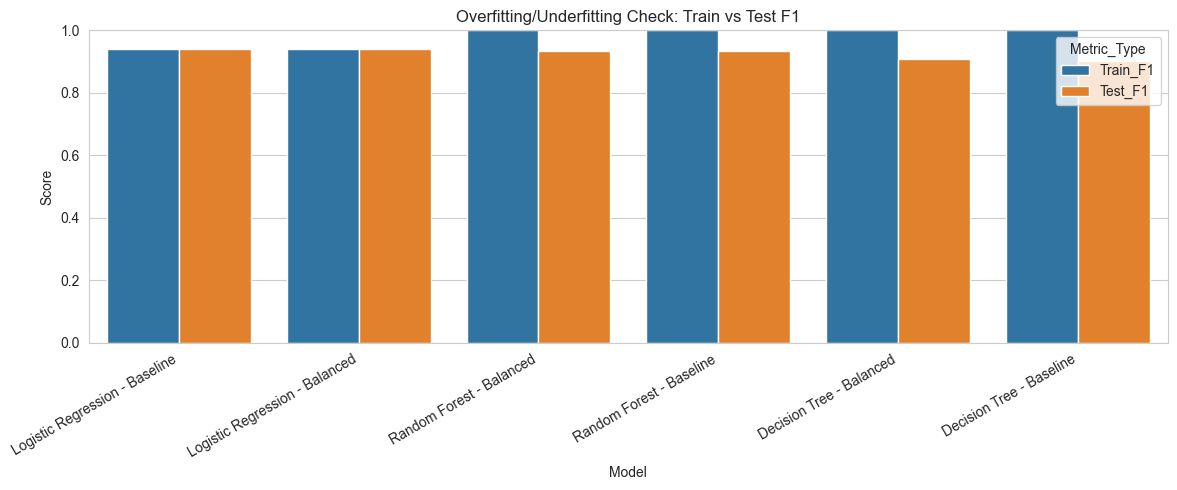

In [72]:
# Explicit Overfitting / Underfitting Analysis
# This cell uses final_df from the comparison step.

if "final_df" not in globals():
    raise ValueError("Run the model comparison cell first so 'final_df' is available.")

analysis_df = final_df.copy()

# Core gap checks
analysis_df["Accuracy_Gap"] = analysis_df["Train_Accuracy"] - analysis_df["Test_Accuracy"]
analysis_df["F1_Gap"] = analysis_df["Train_F1"] - analysis_df["Test_F1"]


def fit_type(row):
    # Rule-based interpretation (simple and practical)
    if row["F1_Gap"] > 0.10 or row["Accuracy_Gap"] > 0.10:
        return "Possible Overfitting"
    if row["Train_F1"] < 0.60 and row["Test_F1"] < 0.60:
        return "Possible Underfitting"
    return "Balanced Fit"


analysis_df["Fit_Type"] = analysis_df.apply(fit_type, axis=1)

cols_to_show = [
    "Model",
    "Train_Accuracy",
    "Test_Accuracy",
    "Accuracy_Gap",
    "Train_F1",
    "Test_F1",
    "F1_Gap",
    "Fit_Type",
]

display(analysis_df[cols_to_show].sort_values(by="Test_F1", ascending=False).reset_index(drop=True))

# Visualization: Train vs Test F1 by model
plot_df = analysis_df[["Model", "Train_F1", "Test_F1"]].copy()
plot_df = plot_df.melt(id_vars="Model", var_name="Metric_Type", value_name="Score")

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric_Type")
plt.title("Overfitting/Underfitting Check: Train vs Test F1")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()